In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.ndimage import median_filter


In [2]:
# Datensatz laden
ims_cube = scipy.io.loadmat("ims_cube.mat")['ims_cube']


Datenform: (128, 128, 191)
Datentyp: float64


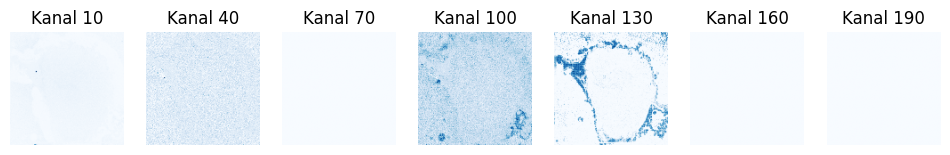

<Figure size 640x480 with 0 Axes>

In [3]:
# 1. Datensatz laden
data = scipy.io.loadmat("ims_cube.mat")
ims_cube = data['ims_cube'] # Datenwürfel mit x,y Position und m/z als Kanalindex
                            # z = eine Liste an Werten

# eintlich ist es kein Würfel
# Man hat ein 2d Bild mit x und y Werten und zu jedem x und y eine Liste [m/z]

# Man hat ein Objekt, schießt mit 191 verschiedenen Lasereinstellungen drauf
# und speichert dann nach jedem Beschuss pro Pixel den "Rückgabewert"
# dadurch hat man dann 190 mal das gleiche Bild nur mit unterschiedlichen Werten,
# da z.B. einmal Proteine(Kanal 34) und einmal Gelatine(Kanal 47) fokussiert sind
# Also nur der Fokus ist unterschiedlich


# Grundlegende Infos über Struktur des Würfels
print("Datenform:", ims_cube.shape)  # (x, y, kanäle)
print("Datentyp:", ims_cube.dtype)

# 2. Beispielhafte Visualisierung einzelner Kanäle
num_channels = ims_cube.shape[2]

# Die Kanäle für output angeben
channels_to_plot = [10, 40, 70, 100, 130, 160, 190]


# Neue Abbildung mit definierter Größe
plt.figure(figsize=(12, 6))

# Schleife über alle ausgewählten Kanäle
for i, ch in enumerate(channels_to_plot, 1):
    # Lege Position für das aktuelle Teilbild fest (1 Zeile, mehrere Spalten)
    plt.subplot(1, len(channels_to_plot), i)

    # Zeige den jeweiligen Kanal als 2D-Bild
    plt.imshow(ims_cube[:, :, ch], cmap='Blues')
    plt.title(f"Kanal {ch}")  # Beschrifte das Teilbild
    plt.axis('off')           # Achsen ausblenden für saubere Darstellung

# Zeige alle Teilbilder nebeneinander an
plt.show()

plt.suptitle("Räumliche Verteilung ausgewählter Kanäle")
plt.show()


### 2. Datenaufbereitung

Zuerst wandeln wir die Quellmatrix in eine zweidimensionale Matrix um, damit wir eine gewöhnliche Featurematrix mit Features und Datenpunkten erhalten. Dies erleichtert die Handhabung erheblich, vor allem bei ---.

In [4]:
# 3D → 2D Umwandlung
print("Ursprüngliche Form des Datenwürfels:", ims_cube.shape)
spectral_matrix = ims_cube.reshape(-1, ims_cube.shape[2])
print("Form der neuen Featurematrix:", spectral_matrix.shape)


Ursprüngliche Form des Datenwürfels: (128, 128, 191)
Form der neuen Featurematrix: (16384, 191)


In [5]:
# Imports für hierarchisches Clustering
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler

print("Alle Imports erfolgreich geladen!")

Alle Imports erfolgreich geladen!


## Funktionen für hierarchisches Clustering

Hier werden alle Clustering-Funktionen definiert, die später an verschiedenen Stellen im Notebook verwendet werden können.

**Verfügbare Funktionen:**

1. `single_linkage_number(data, img_shape, n_clusters=5, n_samples_dendro=1000)` - Single Linkage mit fester Cluster-Anzahl
2. `single_linkage_distance(data, img_shape, distance_threshold=9.0, n_samples_dendro=1000)` - Single Linkage mit Distanz-Threshold
3. `complete_linkage_number(data, img_shape, n_clusters=5, n_samples_dendro=1000)` - Complete Linkage mit fester Cluster-Anzahl
4. `complete_linkage_distance(data, img_shape, distance_threshold=17.0, n_samples_dendro=1000)` - Complete Linkage mit Distanz-Threshold
5. `average_linkage_number(data, img_shape, n_clusters=5, n_samples_dendro=1000)` - Average Linkage mit fester Cluster-Anzahl
6. `average_linkage_distance(data, img_shape, distance_threshold=13.0, n_samples_dendro=1000)` - Average Linkage mit Distanz-Threshold

**Parameter:**
- `data`: Featurematrix (z.B. `spectral_matrix`, `spectral_matrix_std`, `spectral_matrix_tic`)
- `img_shape`: Bildform, normalerweise `ims_cube.shape[:2]`
- `n_clusters`: Anzahl der gewünschten Cluster
- `distance_threshold`: Maximale Distanz für Cluster-Merging
- `n_samples_dendro`: Anzahl der Samples für Dendrogram (Standard: 1000)

In [6]:
def single_linkage_number(data, img_shape, n_clusters=5, n_samples_dendro=1000):
    """
    Single Linkage Clustering mit fester Cluster-Anzahl.
    
    Parameters:
    -----------
    data : ndarray
        Featurematrix (n_pixels, n_features)
    img_shape : tuple
        Form des Bildes (height, width)
    n_clusters : int
        Anzahl der gewünschten Cluster
    n_samples_dendro : int
        Anzahl der Samples für Dendrogram-Visualisierung
    
    Returns:
    --------
    labels : ndarray
        Cluster-Labels für jeden Pixel
    cluster_image : ndarray
        Cluster-Labels in Bildform
    """
    # Clustering durchführen
    single_linkage = AgglomerativeClustering(n_clusters=n_clusters, linkage='single')
    labels = single_linkage.fit_predict(data)
    
    # Zurück in räumliche Form bringen
    height, width = img_shape
    cluster_image = labels.reshape(height, width)
    
    # Sample für Dendrogram
    indices = np.random.choice(data.shape[0], size=min(n_samples_dendro, data.shape[0]), replace=False)
    X_sample = data[indices]
    
    # Visualisierung
    plt.figure(figsize=(12, 5))
    
    # Cluster-Bild
    plt.subplot(1, 2, 1)
    plt.imshow(cluster_image, cmap='tab10')
    plt.title(f"Single Linkage Clustering\n({n_clusters} Cluster)")
    plt.axis('off')
    plt.colorbar(label='Cluster ID')
    
    # Dendrogram
    plt.subplot(1, 2, 2)
    linkage_matrix = linkage(X_sample, method='single')
    dendrogram(linkage_matrix, no_labels=True, color_threshold=0)
    plt.title(f"Dendrogram - Single Linkage\n({n_samples_dendro} Samples)")
    plt.xlabel("Datenpunkt-Index")
    plt.ylabel("Distanz")
    
    plt.tight_layout()
    plt.show()
    
    print(f"Anzahl Cluster: {n_clusters}")
    print(f"Cluster-Größen: {np.bincount(labels)}")
    
    return labels, cluster_image

In [7]:
def single_linkage_distance(data, img_shape, distance_threshold=9.0, n_samples_dendro=1000):
    """
    Single Linkage Clustering mit Distanz-Threshold.
    
    Parameters:
    -----------
    data : ndarray
        Featurematrix (n_pixels, n_features)
    img_shape : tuple
        Form des Bildes (height, width)
    distance_threshold : float
        Maximale Distanz für Cluster-Merging
    n_samples_dendro : int
        Anzahl der Samples für Dendrogram-Visualisierung
    
    Returns:
    --------
    labels : ndarray
        Cluster-Labels für jeden Pixel
    cluster_image : ndarray
        Cluster-Labels in Bildform
    """
    # Clustering durchführen
    single_linkage = AgglomerativeClustering(n_clusters=None, 
                                             linkage='single',
                                             distance_threshold=distance_threshold)
    labels = single_linkage.fit_predict(data)
    
    # Zurück in räumliche Form bringen
    height, width = img_shape
    cluster_image = labels.reshape(height, width)
    
    # Sample für Dendrogram
    indices = np.random.choice(data.shape[0], size=min(n_samples_dendro, data.shape[0]), replace=False)
    X_sample = data[indices]
    
    # Visualisierung
    plt.figure(figsize=(12, 5))
    
    # Cluster-Bild
    plt.subplot(1, 2, 1)
    plt.imshow(cluster_image, cmap='tab10')
    n_clusters_found = len(np.unique(labels))
    plt.title(f"Single Linkage Clustering\n({n_clusters_found} Cluster bei Threshold {distance_threshold})")
    plt.axis('off')
    plt.colorbar(label='Cluster ID')
    
    # Dendrogram mit Threshold-Linie
    plt.subplot(1, 2, 2)
    linkage_matrix = linkage(X_sample, method='single')
    dendrogram(linkage_matrix, no_labels=True, color_threshold=distance_threshold)
    plt.axhline(y=distance_threshold, color='r', linestyle='--', label=f'Threshold = {distance_threshold}')
    plt.title(f"Dendrogram - Single Linkage\n({n_samples_dendro} Samples)")
    plt.xlabel("Datenpunkt-Index")
    plt.ylabel("Distanz")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Distanz-Threshold: {distance_threshold}")
    print(f"Anzahl gefundener Cluster: {n_clusters_found}")
    print(f"Cluster-Größen: {np.bincount(labels)}")
    
    return labels, cluster_image

In [8]:
def complete_linkage_number(data, img_shape, n_clusters=5, n_samples_dendro=1000):
    """
    Complete Linkage Clustering mit fester Cluster-Anzahl.
    
    Parameters:
    -----------
    data : ndarray
        Featurematrix (n_pixels, n_features)
    img_shape : tuple
        Form des Bildes (height, width)
    n_clusters : int
        Anzahl der gewünschten Cluster
    n_samples_dendro : int
        Anzahl der Samples für Dendrogram-Visualisierung
    
    Returns:
    --------
    labels : ndarray
        Cluster-Labels für jeden Pixel
    cluster_image : ndarray
        Cluster-Labels in Bildform
    """
    # Clustering durchführen
    complete_linkage = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete')
    labels = complete_linkage.fit_predict(data)
    
    # Zurück in räumliche Form bringen
    height, width = img_shape
    cluster_image = labels.reshape(height, width)
    
    # Sample für Dendrogram
    indices = np.random.choice(data.shape[0], size=min(n_samples_dendro, data.shape[0]), replace=False)
    X_sample = data[indices]
    
    # Visualisierung
    plt.figure(figsize=(12, 5))
    
    # Cluster-Bild
    plt.subplot(1, 2, 1)
    plt.imshow(cluster_image, cmap='tab10')
    plt.title(f"Complete Linkage Clustering\n({n_clusters} Cluster)")
    plt.axis('off')
    plt.colorbar(label='Cluster ID')
    
    # Dendrogram
    plt.subplot(1, 2, 2)
    linkage_matrix = linkage(X_sample, method='complete')
    dendrogram(linkage_matrix, no_labels=True, color_threshold=0)
    plt.title(f"Dendrogram - Complete Linkage\n({n_samples_dendro} Samples)")
    plt.xlabel("Datenpunkt-Index")
    plt.ylabel("Distanz")
    
    plt.tight_layout()
    plt.show()
    
    print(f"Anzahl Cluster: {n_clusters}")
    print(f"Cluster-Größen: {np.bincount(labels)}")
    
    return labels, cluster_image

In [9]:
def complete_linkage_distance(data, img_shape, distance_threshold=17.0, n_samples_dendro=1000):
    """
    Complete Linkage Clustering mit Distanz-Threshold.
    
    Parameters:
    -----------
    data : ndarray
        Featurematrix (n_pixels, n_features)
    img_shape : tuple
        Form des Bildes (height, width)
    distance_threshold : float
        Maximale Distanz für Cluster-Merging
    n_samples_dendro : int
        Anzahl der Samples für Dendrogram-Visualisierung
    
    Returns:
    --------
    labels : ndarray
        Cluster-Labels für jeden Pixel
    cluster_image : ndarray
        Cluster-Labels in Bildform
    """
    # Clustering durchführen
    complete_linkage = AgglomerativeClustering(n_clusters=None,
                                              linkage='complete',
                                              distance_threshold=distance_threshold)
    labels = complete_linkage.fit_predict(data)
    
    # Zurück in räumliche Form bringen
    height, width = img_shape
    cluster_image = labels.reshape(height, width)
    
    # Sample für Dendrogram
    indices = np.random.choice(data.shape[0], size=min(n_samples_dendro, data.shape[0]), replace=False)
    X_sample = data[indices]
    
    # Visualisierung
    plt.figure(figsize=(12, 5))
    
    # Cluster-Bild
    plt.subplot(1, 2, 1)
    plt.imshow(cluster_image, cmap='tab10')
    n_clusters_found = len(np.unique(labels))
    plt.title(f"Complete Linkage Clustering\n({n_clusters_found} Cluster bei Threshold {distance_threshold})")
    plt.axis('off')
    plt.colorbar(label='Cluster ID')
    
    # Dendrogram mit Threshold-Linie
    plt.subplot(1, 2, 2)
    linkage_matrix = linkage(X_sample, method='complete')
    dendrogram(linkage_matrix, no_labels=True, color_threshold=distance_threshold)
    plt.axhline(y=distance_threshold, color='r', linestyle='--', label=f'Threshold = {distance_threshold}')
    plt.title(f"Dendrogram - Complete Linkage\n({n_samples_dendro} Samples)")
    plt.xlabel("Datenpunkt-Index")
    plt.ylabel("Distanz")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Distanz-Threshold: {distance_threshold}")
    print(f"Anzahl gefundener Cluster: {n_clusters_found}")
    print(f"Cluster-Größen: {np.bincount(labels)}")
    
    return labels, cluster_image

In [10]:
def average_linkage_number(data, img_shape, n_clusters=5, n_samples_dendro=1000):
    """
    Average Linkage Clustering mit fester Cluster-Anzahl.
    
    Parameters:
    -----------
    data : ndarray
        Featurematrix (n_pixels, n_features)
    img_shape : tuple
        Form des Bildes (height, width)
    n_clusters : int
        Anzahl der gewünschten Cluster
    n_samples_dendro : int
        Anzahl der Samples für Dendrogram-Visualisierung
    
    Returns:
    --------
    labels : ndarray
        Cluster-Labels für jeden Pixel
    cluster_image : ndarray
        Cluster-Labels in Bildform
    """
    # Clustering durchführen
    average_linkage = AgglomerativeClustering(n_clusters=n_clusters, linkage='average')
    labels = average_linkage.fit_predict(data)
    
    # Zurück in räumliche Form bringen
    height, width = img_shape
    cluster_image = labels.reshape(height, width)
    
    # Sample für Dendrogram
    indices = np.random.choice(data.shape[0], size=min(n_samples_dendro, data.shape[0]), replace=False)
    X_sample = data[indices]
    
    # Visualisierung
    plt.figure(figsize=(12, 5))
    
    # Cluster-Bild
    plt.subplot(1, 2, 1)
    plt.imshow(cluster_image, cmap='tab10')
    plt.title(f"Average Linkage Clustering\n({n_clusters} Cluster)")
    plt.axis('off')
    plt.colorbar(label='Cluster ID')
    
    # Dendrogram
    plt.subplot(1, 2, 2)
    linkage_matrix = linkage(X_sample, method='average')
    dendrogram(linkage_matrix, no_labels=True, color_threshold=0)
    plt.title(f"Dendrogram - Average Linkage\n({n_samples_dendro} Samples)")
    plt.xlabel("Datenpunkt-Index")
    plt.ylabel("Distanz")
    
    plt.tight_layout()
    plt.show()
    
    print(f"Anzahl Cluster: {n_clusters}")
    print(f"Cluster-Größen: {np.bincount(labels)}")
    
    return labels, cluster_image

In [11]:
def average_linkage_distance(data, img_shape, distance_threshold=13.0, n_samples_dendro=1000):
    """
    Average Linkage Clustering mit Distanz-Threshold.
    
    Parameters:
    -----------
    data : ndarray
        Featurematrix (n_pixels, n_features)
    img_shape : tuple
        Form des Bildes (height, width)
    distance_threshold : float
        Maximale Distanz für Cluster-Merging
    n_samples_dendro : int
        Anzahl der Samples für Dendrogram-Visualisierung
    
    Returns:
    --------
    labels : ndarray
        Cluster-Labels für jeden Pixel
    cluster_image : ndarray
        Cluster-Labels in Bildform
    """
    # Clustering durchführen
    average_linkage = AgglomerativeClustering(n_clusters=None,
                                             linkage='average',
                                             distance_threshold=distance_threshold)
    labels = average_linkage.fit_predict(data)
    
    # Zurück in räumliche Form bringen
    height, width = img_shape
    cluster_image = labels.reshape(height, width)
    
    # Sample für Dendrogram
    indices = np.random.choice(data.shape[0], size=min(n_samples_dendro, data.shape[0]), replace=False)
    X_sample = data[indices]
    
    # Visualisierung
    plt.figure(figsize=(12, 5))
    
    # Cluster-Bild
    plt.subplot(1, 2, 1)
    plt.imshow(cluster_image, cmap='tab10')
    n_clusters_found = len(np.unique(labels))
    plt.title(f"Average Linkage Clustering\n({n_clusters_found} Cluster bei Threshold {distance_threshold})")
    plt.axis('off')
    plt.colorbar(label='Cluster ID')
    
    # Dendrogram mit Threshold-Linie
    plt.subplot(1, 2, 2)
    linkage_matrix = linkage(X_sample, method='average')
    dendrogram(linkage_matrix, no_labels=True, color_threshold=distance_threshold)
    plt.axhline(y=distance_threshold, color='r', linestyle='--', label=f'Threshold = {distance_threshold}')
    plt.title(f"Dendrogram - Average Linkage\n({n_samples_dendro} Samples)")
    plt.xlabel("Datenpunkt-Index")
    plt.ylabel("Distanz")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Distanz-Threshold: {distance_threshold}")
    print(f"Anzahl gefundener Cluster: {n_clusters_found}")
    print(f"Cluster-Größen: {np.bincount(labels)}")
    
    return labels, cluster_image

## Funktionsaufrufe vor Normierung

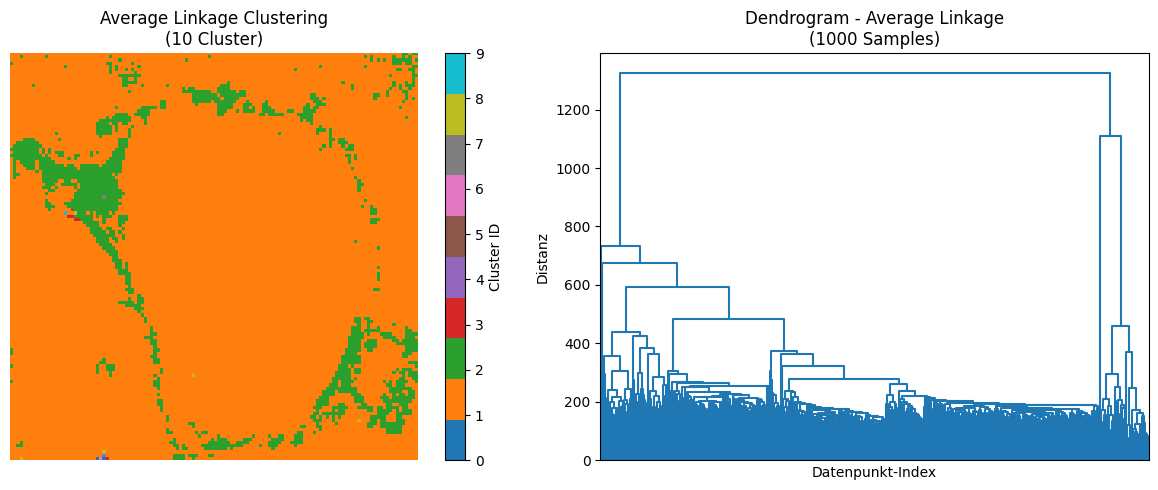

Anzahl Cluster: 10
Cluster-Größen: [    2 14827  1540     5     1     1     1     1     5     1]


(array([1, 1, 1, ..., 1, 1, 1], shape=(16384,)),
 array([[1, 1, 1, ..., 1, 2, 2],
        [1, 1, 1, ..., 2, 1, 1],
        [1, 1, 1, ..., 2, 1, 2],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]], shape=(128, 128)))

In [ ]:
#Die am besten charakterisierenden Funktionsaufrufe:

#single_linkage_distance(spectral_matrix, ims_cube.shape[:2], distance_threshold=200.0)
#single_linkage_number(spectral_matrix, ims_cube.shape[:2], n_clusters=10)

#complete_linkage_number(spectral_matrix, ims_cube.shape[:2], n_clusters=11)
#complete_linkage_distance(spectral_matrix, ims_cube.shape[:2], distance_threshold=800.0)

#average_linkage_distance(spectral_matrix, ims_cube.shape[:2], distance_threshold=410.0)
#average_linkage_number(spectral_matrix, ims_cube.shape[:2], n_clusters=10)

## NORMIERUNG

Verschiedene Normierungsmethoden für die Spektraldaten.

**Verfügbare normalisierte Datenmatrizen nach Ausführung der Normalisierungs-Schritte:**

- `spectral_matrix` - Rohdaten (2D-Umformung des Würfels)
- `spectral_matrix_med` - Nach Medianfilter
- `spectral_matrix_tic` - Nach TIC-Normierung (L1)
- `spectral_matrix_log` - Nach Log-Transformation
- `spectral_matrix_std` - Nach StandardScaler (spaltenweise Normierung)

Sie können jede dieser Matrizen als `data`-Parameter an die Clustering-Funktionen übergeben.

### 1. Medianfilter pro Kanal

In [ ]:
# 1) Spatial median filtering pro Kanal (reduziert pixel-Ausreißer)
from scipy.ndimage import median_filter

height, width = ims_cube.shape[:2]
n_channels = spectral_matrix.shape[1]

spectral_matrix_med = np.empty_like(spectral_matrix)
for ch in range(n_channels):
    channel_image = spectral_matrix[:, ch].reshape(height, width)  # 2D
    channel_med = median_filter(channel_image, size=3)  # 3x3 Medianfilter
    spectral_matrix_med[:, ch] = channel_med.ravel()

print(f"Medianfilter angewendet auf {n_channels} Kanäle")

### 2. TIC-Normierung (zeilenweise)

In [ ]:
# 2) TIC Normalization (zeilenweise): jedes Spektrum durch seine Summe teilen (L1-Normierung)
# jede Zeile hat jetzt Summe 1
row_sums = spectral_matrix.sum(axis=1, keepdims=True)  # shape (n_pixels, 1)
# Vermeide Division durch 0:
row_sums[row_sums == 0] = 1.0
spectral_matrix_tic = spectral_matrix / row_sums

print(f"TIC-Normierung durchgeführt")

### Alternativ: L2-Normierung

In [ ]:
# L2-Normierung (alternativ zu TIC-Normierung)
# Normierung der Spektren (stabil) - jede Zeile hat jetzt Länge 1
norms = np.linalg.norm(spectral_matrix, axis=1, keepdims=True)

# Vermeidet Division durch 0 (fügt Epsilon hinzu wenn Wert = 0)
norms[norms == 0] = 1e-12

spectral_matrix_l2 = spectral_matrix / norms

print(f"L2-Normierung durchgeführt")

### 3. Log-Transform (hohe Peaks vermeiden)

In [ ]:
# 3) Log-Transform (optional, dämpft starke Peaks)
spectral_matrix_log = np.log1p(spectral_matrix_tic)   # log(1 + x), sicher bei 0

print(f"Log-Transformation angewendet")

### 4. Signal-zu-Rausch-Filterung (spaltenweise Auswahl)

In [ ]:
# Signal-zu-Rausch-Filterung (Feature-Selektion)
channel_std = spectral_matrix.std(axis=0)
channel_mean = spectral_matrix.mean(axis=0)
signal_to_noise = channel_mean / (channel_std + 1e-12)

snr_threshold = np.percentile(signal_to_noise, 20)  # unterste 20% entfernen
mask = (channel_std > 1e-6) & (signal_to_noise > snr_threshold)
spectral_matrix = spectral_matrix[:, mask]

print(f"Behaltene Kanäle nach Filterung: {spectral_matrix.shape[1]}")

# AUTOMATISCH ERKENNEN WIE VIEL PROZENT WEG SOLLEN
# VARIANZ PRO KANAL NOCH ANZEIGEN LASSEN IRGENDWIE??

### 5. Spaltenweise Normierung mit StandardScaler

In [ ]:
# 4) Featurewise Standardisierung (spaltenweise) — wichtig vor PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
spectral_matrix_std = scaler.fit_transform(spectral_matrix_med)  # jede Spalte: mean=0, std=1

print(f"StandardScaler angewendet: {spectral_matrix_std.shape}")

## Funktionsaufrufe nach Normierung